[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/da380/PartIIStatistics/blob/main/notebooks/07_bayesian_inference.ipynb)

# 7. Bayesian inference

**What you should get out of this notebook**

- Use Bayes' theorem to update probabilities in the light of data, and see why base rates matter.
- Understand prior, likelihood and posterior, and compute posteriors for simple problems exactly and on a grid.
- Interpret a credible interval, and see how it differs from a confidence interval.
- Understand how the prior matters when data are scarce and fades when data are plentiful.
- Run a simple Markov chain Monte Carlo sampler, the tool that makes Bayesian methods practical.
- Compare hypotheses with the evidence ratio (Bayes factor), and see how it penalises unnecessary parameters.

**Tools introduced**

- `stats.beta`, `stats.binomtest(...).proportion_ci`
- `stats.norm` for the conjugate normal model
- grid evaluation with `np.meshgrid`, and marginalisation by summing
- a hand-written Metropolis sampler using `rng.normal` and `rng.uniform`
- `stats.binom`, `stats.binomtest`, `stats.multivariate_normal(...).logpdf` for evidence calculations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

rng = np.random.default_rng(1)          # random number generator with a fixed seed
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
DATA = "https://raw.githubusercontent.com/da380/PartIIStatistics/main/data/"

## Two views of probability

Everything so far has been **frequentist**: probability is the long-run frequency of an outcome in repeated experiments, parameters are fixed unknown constants, and probability statements are made about *data* and *procedures* (a confidence interval captures the truth in 95% of repetitions; a p-value is the probability of data as extreme as ours if $H_0$ holds). We were careful never to say "the probability that the parameter lies in this interval", because in that view it is not a random quantity.

The **Bayesian** view takes probability to be a measure of *degree of belief*, and applies it to anything uncertain, parameters and hypotheses included. Before seeing data we have a **prior** distribution for the parameters; the data update it to a **posterior** distribution, which is the complete answer to any question about the parameters. The updating rule is Bayes' theorem.

Neither view is "right". They ask different questions and, with plenty of data, usually give similar numerical answers. The Bayesian approach is more direct to interpret and handles complicated problems in a uniform way, at the cost of having to state a prior. Much modern data analysis in geophysics, geochronology and climate science is Bayesian, so you should be comfortable with both.

## Bayes' theorem and the base-rate trap

For two events $A$ and $B$, the definition of conditional probability gives $P(A \cap B) = P(A \mid B)\,P(B) = P(B \mid A)\,P(A)$, and hence

$$
P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)} .
$$

Here is a classic application. A seismic discrimination algorithm classifies events as earthquakes or explosions. It correctly flags 99% of explosions, and wrongly flags 2% of earthquakes. In the region of interest, one event in a thousand is an explosion. An event has just been flagged. What is the probability that it is an explosion?

$$
P(\text{expl} \mid \text{flag}) = \frac{P(\text{flag} \mid \text{expl})\,P(\text{expl})}{P(\text{flag} \mid \text{expl})\,P(\text{expl}) + P(\text{flag} \mid \text{quake})\,P(\text{quake})} .
$$

In [ ]:
p_expl = 0.001
p_flag_given_expl = 0.99
p_flag_given_quake = 0.02

p_flag = p_flag_given_expl * p_expl + p_flag_given_quake * (1 - p_expl)
p_expl_given_flag = p_flag_given_expl * p_expl / p_flag
print(f"P(explosion | flagged) = {p_expl_given_flag:.3f}")

P(explosion | flagged) = 0.047


Only about 5% of flagged events are explosions, despite the algorithm being "99% accurate". The false alarms from the vastly more numerous earthquakes swamp the true detections. The prior probability, the **base rate**, matters enormously, and ignoring it is one of the most common errors in reasoning about evidence. Note the structure of the calculation: prior $\times$ likelihood, normalised over the alternatives.

## Inference for a parameter

The same rule applies to a continuous parameter $\theta$ and data $D$:

$$
p(\theta \mid D) = \frac{p(D \mid \theta)\, p(\theta)}{p(D)}, \qquad\text{or}\qquad
\underbrace{p(\theta \mid D)}_{\text{posterior}} \;\propto\; \underbrace{p(D \mid \theta)}_{\text{likelihood}} \times \underbrace{p(\theta)}_{\text{prior}} .
$$

The likelihood is exactly the function we maximised in Notebook 5. The denominator $p(D)$ does not depend on $\theta$ and is fixed by requiring the posterior to integrate to one. So Bayesian inference is: **write down the likelihood, multiply by the prior, normalise**. Everything we want (a best estimate, an interval, the probability that $\theta$ exceeds some value) is then read off the posterior.

### Example: estimating a proportion

What fraction $\theta$ of Old Faithful eruptions are "short" (under three minutes)? Each eruption is short with probability $\theta$, so $k$ short eruptions out of $n$ is a binomial observation with likelihood $\propto \theta^k (1-\theta)^{n-k}$. A convenient prior is the **beta distribution**, $p(\theta) \propto \theta^{\alpha-1}(1-\theta)^{\beta-1}$, because multiplying it by the binomial likelihood gives another beta distribution:

$$
\text{prior } \mathrm{Beta}(\alpha, \beta) \;\xrightarrow{\;k \text{ of } n\;}\; \text{posterior } \mathrm{Beta}(\alpha + k,\; \beta + n - k).
$$

A prior that leads to a posterior of the same family is called **conjugate**, and makes the calculation trivial. $\mathrm{Beta}(1, 1)$ is the uniform distribution on $[0, 1]$, a natural choice when we claim no prior knowledge. Let us watch the posterior sharpen as eruptions are observed one after another.

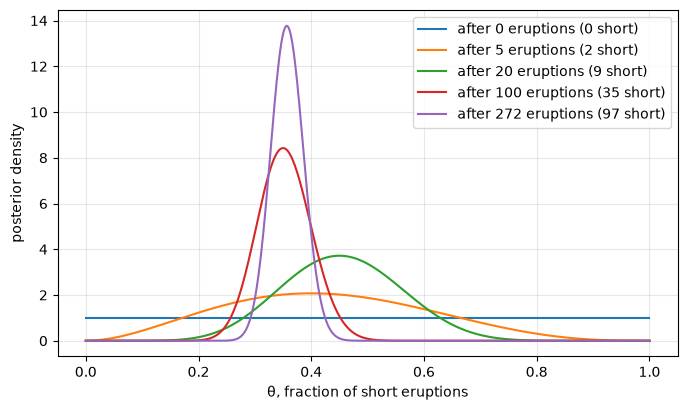

posterior mean = 0.358,  95% credible interval = [0.302, 0.415]
P(θ > 0.4) = 0.073
for comparison, frequentist 95% confidence interval = [0.302, 0.415]


In [ ]:
faithful = pd.read_csv(DATA + "old_faithful.csv")
short = (faithful["eruptions"] < 3).to_numpy()

alpha0, beta0 = 1, 1                  # uniform prior
theta = np.linspace(0, 1, 500)
fig, ax = plt.subplots()
for n in [0, 5, 20, 100, len(short)]:
    k = short[:n].sum()
    post = stats.beta(alpha0 + k, beta0 + n - k)
    ax.plot(theta, post.pdf(theta), label=f"after {n} eruptions ({k} short)")
ax.set(xlabel="θ, fraction of short eruptions", ylabel="posterior density"); ax.legend()
plt.show()

n, k = len(short), short.sum()
post = stats.beta(alpha0 + k, beta0 + n - k)
lo, hi = post.interval(0.95)
print(f"posterior mean = {post.mean():.3f},  95% credible interval = [{lo:.3f}, {hi:.3f}]")
print(f"P(θ > 0.4) = {post.sf(0.4):.3f}")
ci = stats.binomtest(int(k), n).proportion_ci(0.95, method="wilson")
print(f"for comparison, frequentist 95% confidence interval = [{ci.low:.3f}, {ci.high:.3f}]")

The interval $[0.30, 0.42]$ is a **credible interval**: there is a 95% probability, given the data and the prior, that $\theta$ lies in it. That is the statement everyone *wants* a confidence interval to make, and in the Bayesian framework it is legitimate. We can equally ask for the probability that $\theta$ exceeds 0.4, a question with no frequentist counterpart. The frequentist confidence interval is numerically almost identical here; with this much data the two approaches agree, and only their interpretation differs.

### Example: the mean of normal measurements

Suppose we make $n$ measurements $x_i$ of a quantity $\mu$ with known error $\sigma$, and our prior for $\mu$ is normal with mean $m_0$ and standard deviation $s_0$. The normal prior is conjugate to the normal likelihood and the posterior is normal with

$$
\frac{1}{s_n^2} = \frac{1}{s_0^2} + \frac{n}{\sigma^2}, \qquad
m_n = s_n^2 \left( \frac{m_0}{s_0^2} + \frac{n\bar{x}}{\sigma^2} \right).
$$

Compare this with the weighted mean of Notebook 2: the posterior mean is the inverse-variance weighted average of the prior mean and the data mean, and the precisions (inverse variances) add. **The prior behaves exactly like one extra measurement** of $\mu$ with uncertainty $s_0$. This makes the influence of the prior easy to judge: it matters when its precision is comparable to that of the data, and becomes irrelevant as $n$ grows.

As an example: the density of a granite is to be measured. From the literature we take a prior of $2.70 \pm 0.05$ g cm$^{-3}$. Our balance gives measurements with $\sigma = 0.03$ g cm$^{-3}$.

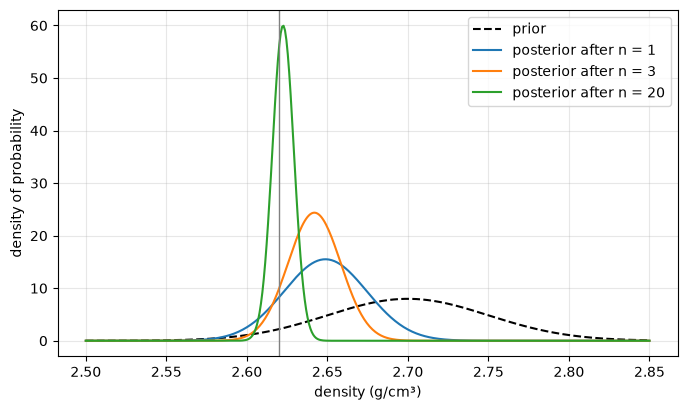

n =  1: data mean = 2.630 ± 0.030;  posterior = 2.649 ± 0.026
n =  3: data mean = 2.635 ± 0.017;  posterior = 2.642 ± 0.016
n = 20: data mean = 2.621 ± 0.007;  posterior = 2.623 ± 0.007


In [ ]:
m0, s0 = 2.70, 0.05
sigma = 0.03
true_density = 2.62
x = stats.norm(true_density, sigma).rvs(20, random_state=rng)

def posterior(x):
    n = len(x)
    prec = 1/s0**2 + n/sigma**2
    return stats.norm(loc=(m0/s0**2 + n*x.mean()/sigma**2) / prec, scale=np.sqrt(1/prec))

mu = np.linspace(2.5, 2.85, 400)
fig, ax = plt.subplots()
ax.plot(mu, stats.norm(m0, s0).pdf(mu), "k--", label="prior")
for n in [1, 3, 20]:
    ax.plot(mu, posterior(x[:n]).pdf(mu), label=f"posterior after n = {n}")
ax.axvline(true_density, color="0.5", lw=1)
ax.set(xlabel="density (g/cm³)", ylabel="density of probability"); ax.legend()
plt.show()

for n in [1, 3, 20]:
    P = posterior(x[:n])
    print(f"n = {n:2d}: data mean = {x[:n].mean():.3f} ± {sigma/np.sqrt(n):.3f};  posterior = {P.mean():.3f} ± {P.std():.3f}")

With a single measurement the posterior sits between the prior and the datum, weighted towards the datum because it is the more precise. By $n = 20$ the prior has almost no influence and the posterior mean is essentially the sample mean. This is the general pattern: **a prior matters when data are scarce, and is swamped when they are plentiful**. If a result depends strongly on the prior, that is the analysis telling you that the data alone do not settle the question, which is worth knowing.

## Posteriors on a grid: the straight line revisited

Conjugate priors are rare luxuries. For a general problem with a few parameters, the simplest approach is to evaluate the posterior numerically on a grid. Take the straight-line fit of Notebook 5, with normal errors and flat priors on $a$ and $b$. Then

$$
p(a, b \mid D) \propto L(a, b) \propto \exp\!\left[-\tfrac{1}{2}\chi^2(a, b)\right],
$$

so the posterior is a simple function of the same $\chi^2$ surface we contoured before. From the two-dimensional posterior we obtain the **marginal** posterior of the slope by integrating out the intercept, $p(a \mid D) = \int p(a, b \mid D)\, \mathrm{d}b$, which on a grid is a sum over columns. Marginalisation is the Bayesian way of handling **nuisance parameters**, those we must include but do not care about; it averages over their uncertainty rather than fixing them at their best values.

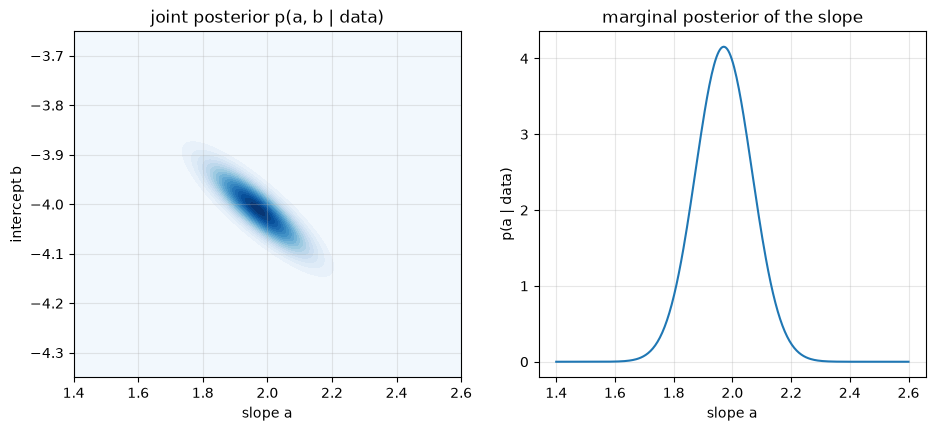

posterior for the slope: mean = 1.971, sd = 0.096, 95% credible interval = [1.780, 2.157]
least squares:           a = 1.971 ± 0.096 (standard error with known σ)


In [ ]:
n = 50
x = np.linspace(0, 1, n)
sigma = 0.2
y = 2*x - 4 + stats.norm(0, sigma).rvs(n, random_state=rng)

aa = np.linspace(1.4, 2.6, 300)
bb = np.linspace(-4.35, -3.65, 300)
A, B = np.meshgrid(aa, bb)
chi2 = np.sum(((y[:, None, None] - (A[None]*x[:, None, None] + B[None])) / sigma)**2, axis=0)
post = np.exp(-0.5 * (chi2 - chi2.min()))
post /= post.sum() * (aa[1]-aa[0]) * (bb[1]-bb[0])          # normalise to unit integral

marg_a = post.sum(axis=0) * (bb[1]-bb[0])                    # integrate over b
marg_b = post.sum(axis=1) * (aa[1]-aa[0])                    # integrate over a

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].contourf(A, B, post, levels=20, cmap="Blues")
ax[0].set(xlabel="slope a", ylabel="intercept b", title="joint posterior p(a, b | data)")
ax[1].plot(aa, marg_a)
ax[1].set(xlabel="slope a", ylabel="p(a | data)", title="marginal posterior of the slope")
plt.show()

cdf_a = np.cumsum(marg_a) * (aa[1]-aa[0])
lo, hi = np.interp([0.025, 0.975], cdf_a, aa)
a_mean = np.sum(aa * marg_a) * (aa[1]-aa[0])
a_sd = np.sqrt(np.sum((aa - a_mean)**2 * marg_a) * (aa[1]-aa[0]))
print(f"posterior for the slope: mean = {a_mean:.3f}, sd = {a_sd:.3f}, 95% credible interval = [{lo:.3f}, {hi:.3f}]")
lr = stats.linregress(x, y)
print(f"least squares:           a = {lr.slope:.3f} ± {np.sqrt(sigma**2 / np.sum((x - x.mean())**2)):.3f} (standard error with known σ)")

With flat priors the posterior mean coincides with the least-squares estimate, the posterior standard deviation with the standard error, and the 95% credible interval with the 95% confidence interval. For linear models with normal errors and flat priors, Bayesian and frequentist answers are numerically identical; the difference lies entirely in what the interval *means*.

### An informative prior

Now suppose physics tells us, independently of these data, that the slope should be $2.3 \pm 0.1$. We multiply the likelihood by this prior.

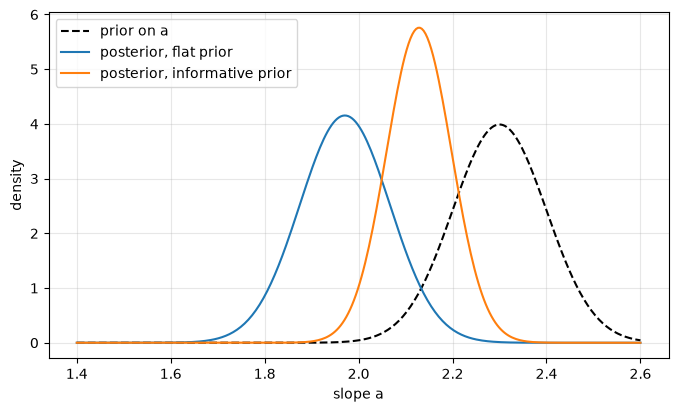

flat prior:        a = 1.971 ± 0.096
informative prior: a = 2.129 ± 0.069


In [ ]:
prior_a = stats.norm(2.3, 0.1)
post2 = post * prior_a.pdf(A)
post2 /= post2.sum() * (aa[1]-aa[0]) * (bb[1]-bb[0])
marg_a2 = post2.sum(axis=0) * (bb[1]-bb[0])

fig, ax = plt.subplots()
ax.plot(aa, prior_a.pdf(aa), "k--", label="prior on a")
ax.plot(aa, marg_a, label="posterior, flat prior")
ax.plot(aa, marg_a2, label="posterior, informative prior")
ax.set(xlabel="slope a", ylabel="density"); ax.legend()
plt.show()

a_mean2 = np.sum(aa * marg_a2) * (aa[1]-aa[0])
a_sd2 = np.sqrt(np.sum((aa - a_mean2)**2 * marg_a2) * (aa[1]-aa[0]))
print(f"flat prior:        a = {a_mean:.3f} ± {a_sd:.3f}")
print(f"informative prior: a = {a_mean2:.3f} ± {a_sd2:.3f}")

The posterior moves towards the prior and narrows, since the prior adds information. Whether this is legitimate depends entirely on whether the prior is *justified*: if the "physics" was wrong, the prior has pulled the answer away from the truth. Priors should be stated explicitly and their influence tested by varying them (a **sensitivity analysis**). A flat prior is not automatically "objective" either: flat in $a$ is not flat in $1/a$ or $\ln a$, so even the uninformative choice involves a decision about parameterisation. With good data these subtleties do not matter; with poor data they do, and the Bayesian framework at least makes them visible.

## Markov chain Monte Carlo

A grid is fine for two parameters. For ten it is hopeless: a grid of 100 points per dimension has $10^{20}$ cells. Real problems, with dozens or thousands of parameters, need a different approach. **Markov chain Monte Carlo (MCMC)** generates a sequence of random parameter values whose distribution *is* the posterior, without ever normalising it. From the samples, posterior means, intervals and marginals are just averages and histograms, exactly as with Monte Carlo error propagation in Notebook 3.

The simplest MCMC method is the **Metropolis algorithm**. Starting from some $\boldsymbol{\theta}$:

1. Propose a move to $\boldsymbol{\theta}'$ by adding a random step.
2. Compute the ratio of posterior densities, $r = p(\boldsymbol{\theta}' \mid D) / p(\boldsymbol{\theta} \mid D)$. Only the *unnormalised* posterior is needed.
3. If $r \ge 1$ accept the move. Otherwise accept it with probability $r$; if rejected, stay put (and record the current point again).
4. Repeat.

The chain wanders preferentially into regions of high posterior density and, after an initial **burn-in** period, its visits are distributed according to the posterior. Here it is for the straight-line problem, in a dozen lines. In practice we work with the logarithm of the posterior to avoid overflow, so the acceptance test compares $\ln r$ with the logarithm of a uniform random number.

acceptance rate = 0.41


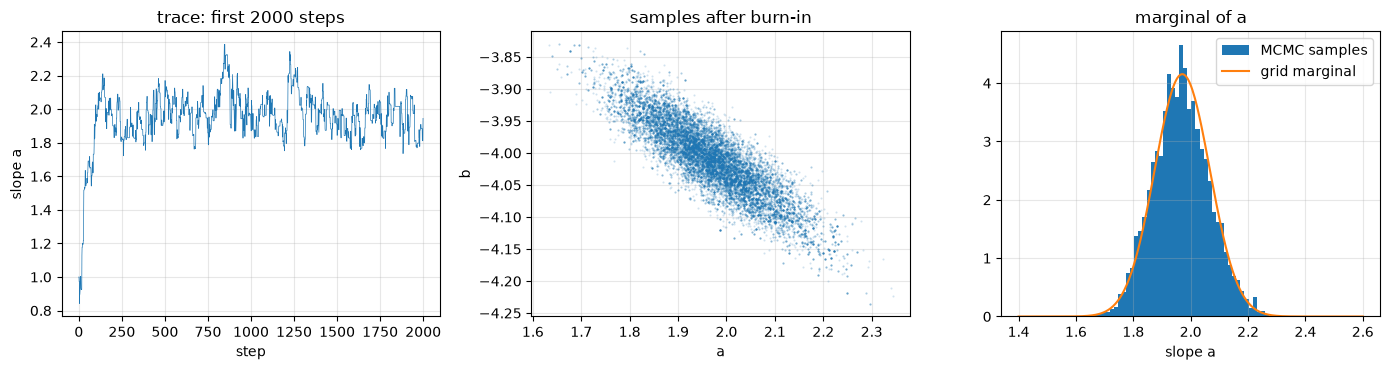

MCMC: a = 1.967 ± 0.098,  b = -4.009 ± 0.057,  95% interval for a = [1.783, 2.165]


In [ ]:
def log_posterior(theta):
    a, b = theta
    return -0.5 * np.sum(((y - (a*x + b)) / sigma)**2)          # flat priors: log posterior = -χ²/2

n_steps = 20_000
step = np.array([0.08, 0.05])                                 # proposal standard deviations
theta = np.array([1.0, -3.0])                                 # a deliberately poor starting point
lp = log_posterior(theta)
chain = np.empty((n_steps, 2)); accepted = 0
for i in range(n_steps):
    proposal = theta + step * rng.normal(size=2)
    lp_prop = log_posterior(proposal)
    if np.log(rng.uniform()) < lp_prop - lp:
        theta, lp = proposal, lp_prop
        accepted += 1
    chain[i] = theta
print(f"acceptance rate = {accepted / n_steps:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].plot(chain[:2000, 0], lw=0.5); ax[0].set(xlabel="step", ylabel="slope a", title="trace: first 2000 steps")
burn = 1000
ax[1].plot(chain[burn:, 0], chain[burn:, 1], ".", ms=1, alpha=0.2); ax[1].set(xlabel="a", ylabel="b", title="samples after burn-in")
ax[2].hist(chain[burn:, 0], bins=50, density=True, label="MCMC samples")
ax[2].plot(aa, marg_a, "C1", label="grid marginal"); ax[2].set(xlabel="slope a", title="marginal of a"); ax[2].legend()
plt.tight_layout(); plt.show()

s = chain[burn:]
print(f"MCMC: a = {s[:, 0].mean():.3f} ± {s[:, 0].std():.3f},  b = {s[:, 1].mean():.3f} ± {s[:, 1].std():.3f},"
      f"  95% interval for a = [{np.percentile(s[:, 0], 2.5):.3f}, {np.percentile(s[:, 0], 97.5):.3f}]")

The trace shows the chain moving from its poor starting point into the high-probability region within a few hundred steps, after which it fluctuates around the posterior. Discarding this burn-in, the histogram of the samples reproduces the grid marginal, and the marginal of $b$ comes free.

Some practical points. The step size matters: too small and the chain crawls, too large and almost every proposal is rejected; an acceptance rate of 20–50% is a good sign. Successive samples are correlated, so 19,000 samples are worth fewer independent draws; run the chain longer than you think necessary and check that different starting points give the same answer. And the Metropolis algorithm, while adequate here, is far from the state of the art: packages such as `emcee`, `PyMC` and `Stan` implement much more efficient samplers and are what you would use in practice. The principle is the same.

## Comparing hypotheses: the evidence and Bayes factors

So far we have estimated parameters within a single model. Often the question is which of two *models* is better supported by the data: is the geyser's short-eruption fraction exactly one third, or something else? Is a straight line enough, or is there curvature? The frequentist answer is a hypothesis test with a p-value. The Bayesian answer applies Bayes' theorem to the hypotheses themselves.

For hypotheses $H_0$ and $H_1$,

$$
\frac{P(H_1 \mid D)}{P(H_0 \mid D)} = \underbrace{\frac{p(D \mid H_1)}{p(D \mid H_0)}}_{B_{10},\ \text{the Bayes factor}} \times \frac{P(H_1)}{P(H_0)} ,
$$

so the posterior odds are the prior odds multiplied by the **Bayes factor**, the ratio of the probabilities of the data under the two hypotheses. Those probabilities are the **evidence** (or marginal likelihood) of each model,

$$
p(D \mid H) = \int p(D \mid \theta, H)\, p(\theta \mid H)\, \mathrm{d}\theta ,
$$

the likelihood *averaged over the prior* for the model's parameters. This is the normalising denominator that we discarded when estimating parameters; for comparing models it is the whole point. A rough scale, due to Jeffreys: a Bayes factor of 3 is barely worth mentioning, 10 is substantial, 30 strong, and 100 decisive, with the reciprocals meaning the same in the other direction.

The evidence has a property that makes it very different from a maximised likelihood. A model with extra free parameters can always fit at least as well at its *best* parameters, but its prior probability is spread over a larger volume of parameter space, most of which fits badly. Averaging over the prior therefore penalises the extra freedom unless the data really need it: an automatic **Occam's razor**. This is why Bayes factors can favour the simpler model, something a likelihood ratio can never do.

### Example: is the short-eruption fraction exactly one third?

Let $H_0$ be "$\theta = 1/3$", with no free parameter, and $H_1$ be "$\theta$ is unknown", with a uniform prior. For $k$ short eruptions out of $n$, the evidence for $H_0$ is just the binomial probability of the data at $\theta = 1/3$. For $H_1$ it is the binomial probability integrated over the uniform prior, which is exactly $1/(n+1)$: the average over $\theta$ of $\binom{n}{k}\theta^k(1-\theta)^{n-k}$ does not depend on $k$ at all. So

$$
B_{01} = \frac{p(D \mid H_0)}{p(D \mid H_1)} = (n+1)\,\binom{n}{k}\left(\tfrac{1}{3}\right)^{k}\left(\tfrac{2}{3}\right)^{n-k} .
$$

We compute it as the data accumulate, alongside the frequentist p-value for the same null.

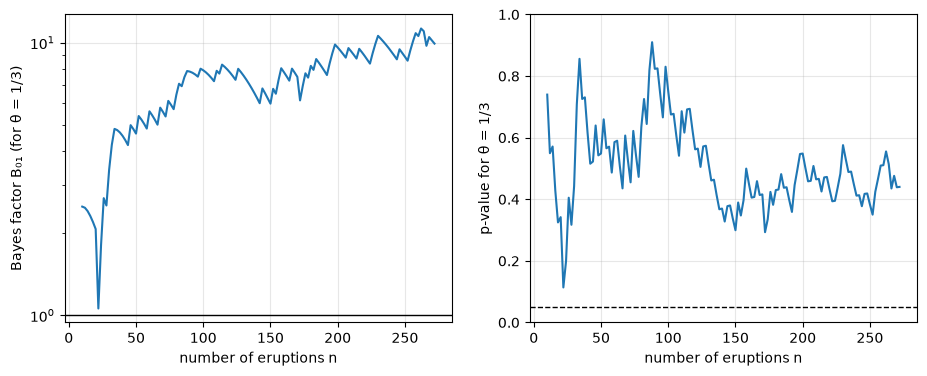

all 272 eruptions, 97 short (fraction 0.357):  B01 = 9.92,  p-value = 0.440


In [ ]:
def bayes_factor_01(k, n, theta0=1/3):
    return (n + 1) * stats.binom(n, theta0).pmf(k)          # evidence for H0 / evidence for H1 (uniform prior)

ns = np.arange(10, len(short) + 1, 2)
B01 = np.array([bayes_factor_01(short[:n].sum(), n) for n in ns])
pvals = np.array([stats.binomtest(int(short[:n].sum()), n, 1/3).pvalue for n in ns])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(ns, B01); ax[0].axhline(1, color="k", lw=1)
ax[0].set(xlabel="number of eruptions n", ylabel="Bayes factor B₀₁ (for θ = 1/3)")
ax[1].plot(ns, pvals); ax[1].axhline(0.05, color="k", lw=1, ls="--")
ax[1].set(xlabel="number of eruptions n", ylabel="p-value for θ = 1/3", ylim=(0, 1))
plt.show()

n, k = len(short), short.sum()
print(f"all {n} eruptions, {k} short (fraction {k/n:.3f}):  B01 = {bayes_factor_01(k, n):.2f},  p-value = {stats.binomtest(int(k), n, 1/3).pvalue:.3f}")

With all the data the Bayes factor is about 10 *in favour* of the point hypothesis $\theta = 1/3$: the observed fraction of 0.357 is close enough to one third that the alternative, which had to spread its bets over the whole interval, is penalised for its vagueness. The p-value, at about 0.4, says only that the data are not surprising under $H_0$; it can never accumulate support *for* a null hypothesis, however much data arrives (Exercise 4 makes this precise). The two are answering different questions, and the Bayesian one, "which hypothesis is better supported?", is often the one actually being asked.

The answer does depend on the prior for $\theta$ under $H_1$. Had we used a prior concentrated near $1/3$, the two hypotheses would have been nearly indistinguishable and $B_{01}$ close to 1; a prior spread over $[0, 1]$ is the most demanding alternative. This sensitivity to the prior is real and should be reported, but it is not arbitrary: the prior *is* the alternative hypothesis, and saying "some other value of $\theta$" without saying which values are plausible is not a hypothesis at all.

### Example: line or quadratic?

Return to the straight-line data. Is there evidence for curvature? Compare $M_1$: $y = ax + b$ with $M_2$: $y = ax + b + cx^2$. Both are linear in their parameters with normal errors, and with normal priors on the parameters the evidence has a closed form: the data vector $\mathbf{y}$ is itself normally distributed, with mean $\mathbf{G}\boldsymbol{\mu}_0$ and covariance $\mathbf{G}\mathbf{C}_0\mathbf{G}^T + \sigma^2\mathbf{I}$, where $\mathbf{G}$ is the design matrix and $\boldsymbol{\mu}_0$, $\mathbf{C}_0$ the prior mean and covariance. So the evidence is a multivariate normal density evaluated at the observed $\mathbf{y}$, and `scipy` will compute it. (For nonlinear models the integral has to be done numerically, by a grid for a few parameters or by specialised sampling methods for more.)

We take broad priors of standard deviation 5 on $a$ and $b$ in both models, and look at how the Bayes factor depends on the prior width for the curvature $c$.

In [ ]:
def log_evidence(G, y, sigma, prior_sd):
    # linear model y = G θ + e, with θ ~ N(0, diag(prior_sd²)) and e ~ N(0, σ² I)
    cov = G @ np.diag(np.square(prior_sd)) @ G.T + sigma**2 * np.eye(len(y))
    return stats.multivariate_normal(mean=np.zeros(len(y)), cov=cov).logpdf(y)

G1 = np.column_stack([x, np.ones_like(x)])
G2 = np.column_stack([x, np.ones_like(x), x**2])

lnZ1 = log_evidence(G1, y, sigma, [5, 5])
print("data generated from a straight line:")
for sd_c in [0.1, 1, 10, 100]:
    lnZ2 = log_evidence(G2, y, sigma, [5, 5, sd_c])
    print(f"   prior sd on c = {sd_c:5.1f}:  ln B21 = {lnZ2 - lnZ1:6.2f},  B21 = {np.exp(lnZ2 - lnZ1):.3g}")

# For comparison, the best-fit chi-squared of each model
chi2_1 = np.sum(((y - G1 @ np.linalg.lstsq(G1, y, rcond=None)[0]) / sigma)**2)
chi2_2 = np.sum(((y - G2 @ np.linalg.lstsq(G2, y, rcond=None)[0]) / sigma)**2)
print(f"   best-fit χ²: line {chi2_1:.1f}, quadratic {chi2_2:.1f}  (the quadratic always fits at least as well)")

data generated from a straight line:
   prior sd on c =   0.1:  ln B21 =  -0.03,  B21 = 0.967
   prior sd on c =   1.0:  ln B21 =  -1.03,  B21 = 0.356
   prior sd on c =  10.0:  ln B21 =  -3.27,  B21 = 0.0381
   prior sd on c = 100.0:  ln B21 =  -5.57,  B21 = 0.00381
   best-fit χ²: line 43.3, quadratic 43.2  (the quadratic always fits at least as well)


The quadratic fits slightly better at its best parameters, as it must, but for any prior wide enough to allow visible curvature the Bayes factor favours the straight line, and does so more strongly the wider the prior on $c$: the more curvature the alternative allows, the more of its prior probability is wasted on curvatures the data rule out. (In the limit of an infinitely wide prior the simpler model always wins, whatever the data; this is the **Lindley paradox**, and it is the reason improper "flat" priors cannot be used for model comparison, though they are harmless for parameter estimation.)

Now generate data that really are curved, and repeat.

In [ ]:
y_curved = 2*x - 4 + 1.5*x**2 + stats.norm(0, sigma).rvs(len(x), random_state=rng)
lnZ1 = log_evidence(G1, y_curved, sigma, [5, 5])
print("data generated from a quadratic with c = 1.5:")
for sd_c in [0.1, 1, 10, 100]:
    lnZ2 = log_evidence(G2, y_curved, sigma, [5, 5, sd_c])
    print(f"   prior sd on c = {sd_c:5.1f}:  ln B21 = {lnZ2 - lnZ1:6.2f}")

data generated from a quadratic with c = 1.5:
   prior sd on c =   0.1:  ln B21 =   0.78
   prior sd on c =   1.0:  ln B21 =   9.14
   prior sd on c =  10.0:  ln B21 =   8.23
   prior sd on c = 100.0:  ln B21 =   5.95


Now the evidence for the quadratic is overwhelming for any reasonable prior: when the data demand the extra parameter, the Occam penalty is a small price. Only the very narrow prior (sd 0.1, which barely allows $c = 1.5$) gives weak support, and that is because it is the wrong alternative. Note too that the evidence still falls slowly as the prior widens beyond what is needed; the penalty for vagueness never goes away.

Two practical notes. The evidence integral is expensive for models with many parameters, and the approximation $\ln p(D \mid H) \approx \ln L_{\max} - \tfrac{k}{2}\ln n$ (for $k$ parameters and $n$ data), which gives the **Bayesian information criterion**, is often used instead; it captures the Occam penalty without needing a prior, at the cost of being only a large-$n$ approximation. And model comparison of this kind assumes that one of the models is *right*; if both are wrong, the Bayes factor tells you which is less wrong, and posterior predictive checks (does the model reproduce the features of the data?) are the necessary complement.

## Bayesian and frequentist: a comparison

| | Frequentist | Bayesian |
|---|---|---|
| Parameters are | fixed unknown constants | uncertain quantities with distributions |
| Probability applies to | data and procedures | anything uncertain, including parameters |
| Prior information | not used formally | required, stated as a prior distribution |
| Point estimate | maximum likelihood | posterior mean, median or mode |
| Interval | confidence: covers the truth in 95% of repetitions | credible: 95% probability the truth is inside |
| Nuisance parameters | profile (optimise over them) | marginalise (integrate over them) |
| Comparing hypotheses | a test with a p-value against the null | the Bayes factor (evidence ratio), which can favour either |
| Model checking | residual tests | posterior predictive checks |
| Main computation | optimisation | integration, usually by MCMC |

With plentiful data and weak priors the two give the same numbers, and most working scientists move between them as convenient. The Bayesian approach is more natural when prior information is genuinely available, when parameters are many and the question is about a few, and when the answer needed is a probability. The frequentist approach needs no prior, and its tests and error rates are well understood. Whichever you use, say which, and say what your intervals mean.

**Further reading.** D. S. Sivia, *Data Analysis: A Bayesian Tutorial* (Oxford) is short and written for physical scientists.

## Exercises

### Exercise 1

Repeat the beta-binomial calculation for the fraction of short eruptions with a strongly informative prior $\mathrm{Beta}(20, 20)$ (which believes the fraction is close to 0.5). Compare the posteriors from the flat prior and this prior after 10 eruptions and after all 272. Plot them. When does the prior matter?

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, n in zip(ax, [10, len(short)]):
    k = short[:n].sum()
    for (a0, b0), name in [((1, 1), "flat prior"), ((20, 20), "Beta(20, 20) prior")]:
        P = stats.beta(a0 + k, b0 + n - k)
        a.plot(theta, P.pdf(theta), label=f"{name}: mean {P.mean():.3f}")
    a.set(xlabel="θ", title=f"after {n} eruptions ({k} short)"); a.legend()
plt.show()
```

After 10 eruptions the two posteriors differ substantially: the informative prior is worth 40 pseudo-observations and dominates. After 272 the data overwhelm it and the posteriors nearly coincide.

</details>

### Exercise 2

*A conjugate model for the Gutenberg–Richter $b$-value.* In Notebook 5 the magnitudes above $M_c$ were modelled as exponential with rate $\beta = b \ln 10$, i.e. likelihood $\prod_i \beta e^{-\beta m_i}$ where $m_i = M_i - M_c$. The gamma distribution is conjugate: a prior $\mathrm{Gamma}(\alpha_0, \text{rate } \lambda_0)$ gives the posterior $\mathrm{Gamma}(\alpha_0 + n, \text{rate } \lambda_0 + \sum_i m_i)$. Using the whole catalogue with $M_c = 4.95$ and a weak prior ($\alpha_0 = 1$, $\lambda_0 = 0.01$), find the posterior mean and 95% credible interval for $b$, and compare with the maximum likelihood value and its standard error $b/\sqrt{n}$. (`stats.gamma(a, scale=1/rate)`.)

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
quakes = pd.read_csv(DATA + "usgs_earthquakes_M5_2014_2023.csv")
m = quakes["mag"].to_numpy() - 4.95
n = len(m)
post_beta = stats.gamma(1 + n, scale=1/(0.01 + m.sum()))       # posterior for β = b ln 10
b_samples = post_beta.rvs(100_000, random_state=rng) / np.log(10)
lo, hi = np.percentile(b_samples, [2.5, 97.5])
b_ml = np.log10(np.e) / m.mean()
print(f"posterior for b: mean = {b_samples.mean():.4f}, sd = {b_samples.std():.4f}, 95% credible interval = [{lo:.4f}, {hi:.4f}]")
print(f"maximum likelihood: b = {b_ml:.4f} ± {b_ml/np.sqrt(n):.4f}")
```

With 17,000 events the posterior is very sharp, and its mean and standard deviation agree with the maximum likelihood estimate and its standard error to three decimal places. (Sampling from the posterior for $\beta$ and transforming to $b$ is the easiest way to get the interval for $b$; one could also use `post_beta.interval(0.95)` and divide by $\ln 10$.)

</details>

### Exercise 3

Modify the Metropolis sampler to sample the posterior for the $b$-value of the previous exercise, using the log-likelihood $n \ln\beta - \beta \sum_i m_i$ and a flat prior on $\beta > 0$ (return `-np.inf` for $\beta \le 0$). Check that the histogram of the samples matches the gamma posterior. Try a step size that is far too large and one far too small and look at the trace plots.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
S = m.sum()
def log_post_beta(beta):
    return n*np.log(beta) - beta*S if beta > 0 else -np.inf

def metropolis(step, n_steps=20_000, start=1.0):
    beta, lp = start, log_post_beta(start)
    chain = np.empty(n_steps); acc = 0
    for i in range(n_steps):
        prop = beta + step*rng.normal()
        lpp = log_post_beta(prop)
        if np.log(rng.uniform()) < lpp - lp:
            beta, lp, acc = prop, lpp, acc + 1
        chain[i] = beta
    return chain, acc/n_steps

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
for a, step in zip(ax, [0.0005, 0.03, 2.0]):
    chain, rate = metropolis(step)
    a.plot(chain[:3000], lw=0.5); a.set(title=f"step {step}: acceptance {rate:.2f}", xlabel="step", ylabel="β")
plt.tight_layout(); plt.show()

chain, _ = metropolis(0.03)
bs = chain[2000:] / np.log(10)
fig, ax = plt.subplots()
ax.hist(bs, bins=50, density=True, label="MCMC")
bb_ = np.linspace(bs.min(), bs.max(), 200)
ax.plot(bb_, post_beta.pdf(bb_*np.log(10))*np.log(10), "C1", label="gamma posterior")
ax.set(xlabel="b"); ax.legend(); plt.show()
print(f"MCMC: b = {bs.mean():.4f} ± {bs.std():.4f}")
```

The tiny step gives a chain that accepts almost everything but moves so slowly that 3000 steps do not even reach the posterior; the huge step is rejected almost always and the trace is a staircase. The intermediate step mixes well and its histogram matches the exact gamma posterior.

</details>

### Exercise 4

Simulate coin tosses from a genuinely fair coin ($\theta = 1/2$) and, as the number of tosses $n$ grows to 10,000, compute both the Bayes factor $B_{01}$ for "$\theta = 1/2$" against a uniform alternative, and the p-value for the same null. Plot both against $n$ on a log axis. What does each do as the evidence accumulates? Repeat once or twice with different random seeds.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
tosses = stats.bernoulli(0.5).rvs(10_000, random_state=rng)
ns = np.unique(np.logspace(1, 4, 60).astype(int))
B01 = [bayes_factor_01(tosses[:n].sum(), n, 0.5) for n in ns]
pv = [stats.binomtest(int(tosses[:n].sum()), n, 0.5).pvalue for n in ns]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].loglog(ns, B01); ax[0].axhline(1, color="k", lw=1); ax[0].set(xlabel="n", ylabel="B₀₁ for a fair coin")
ax[1].semilogx(ns, pv); ax[1].axhline(0.05, color="k", lw=1, ls="--"); ax[1].set(xlabel="n", ylabel="p-value", ylim=(0, 1))
plt.show()
```

The Bayes factor grows steadily in favour of the true hypothesis, roughly as $\sqrt{n}$, reaching decisive support by a few thousand tosses. The p-value wanders around at random and never settles: under a true null it is uniformly distributed at every $n$, so it dips below 0.05 about one time in twenty no matter how much data you have. A p-value cannot accumulate evidence for a null hypothesis; a Bayes factor can, which is one reason it is the natural tool for questions of the form "is this simple hypothesis adequate?"

</details>